In [ ]:
import pandas as pd

df1 = pd.read_csv("Monday-WorkingHours.pcap_ISCX.csv")
df2 = pd.read_csv("Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
df3 = pd.read_csv("Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv")

df = pd.concat([df1, df2, df3], axis=0)

df.shape

(1042130, 79)

In [ ]:
df.shape
df[' Label'].value_counts()

,count
Label,
BENIGN,755173
PortScan,158930
DDoS,128027


In [ ]:
#Given column names have space in front of feature name
df.columns = df.columns.str.strip()

In [ ]:
#We convert: BENIGN → 0 PortScan → 1 DDoS → 1
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

df['Label'].value_counts()

,count
Label,
0,755173
1,286957


In [ ]:
import numpy as np

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

df.shape

(1041288, 79)

In [ ]:
#Feature Engineering starts now
df.dtypes.value_counts()


,count
int64,55
float64,24


In [ ]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

In [ ]:
list(df.columns)

['Destination Port',
 'Flow Duration',
 'Total Fwd Packets',
 'Total Backward Packets',
 'Total Length of Fwd Packets',
 'Total Length of Bwd Packets',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Min Packet Length',
 'Max Packet Length',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag Count',
 'SYN Flag Count',
 'RST Flag Count',
 'PSH Flag Count',
 'ACK Flag Count',
 'UR

In [ ]:
import pandas as pd

df = pd.read_csv("week2Output.csv")
df.columns.tolist()

['Destination Port',
 'Flow Duration',
 'Total Fwd Packets',
 'Total Backward Packets',
 'Total Length of Fwd Packets',
 'Total Length of Bwd Packets',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Min Packet Length',
 'Max Packet Length',
 'Packet Length Mean',
 'Packet Length Std',
 'Average Packet Size',
 'Fwd Packet Length Mean',
 'Bwd Packet Length Mean',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Fwd IAT Mean',
 'Bwd IAT Mean',
 'FIN Flag Count',
 'SYN Flag Count',
 'RST Flag Count',
 'PSH Flag Count',
 'ACK Flag Count',
 'URG Flag Count',
 'ECE Flag Count',
 'Label']

In [ ]:
'Protocol' in df.columns

False

In [ ]:
selected_features = [
    'Destination Port',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Min Packet Length',
    'Max Packet Length',
    'Packet Length Mean',
    'Packet Length Std',
    'Flow Duration',
    'Flow IAT Mean',
    'Flow IAT Std',
    'SYN Flag Count',
    'ACK Flag Count',
    'FIN Flag Count',
    'RST Flag Count',
    'PSH Flag Count'
]

df_minimal = df_raw[selected_features + ['Label']]
df_minimal.shape

(1041288, 18)

In [ ]:
df_final = df[selected_features + ['Label']]
df_final.shape

(759613, 18)

In [ ]:
df_final.to_csv("cicids_binary_production_week2.csv", index=False)

In [ ]:
df_final.shape
df_final['Label'].value_counts()

,count
Label,
0,472784
1,286829


In [ ]:
df_final.describe().T

,count,mean,std,min,25%,50%,75%,max
Destination Port,759613.0,8.848840e+03,1.862761e+04,0.0,80.000000,443.000000,3.351000e+03,6.553400e+04
Total Fwd Packets,759613.0,8.117715e+00,7.318868e+02,1.0,1.000000,2.000000,5.000000e+00,2.197590e+05
Total Backward Packets,759613.0,8.791336e+00,9.633913e+02,0.0,1.000000,1.000000,5.000000e+00,2.919220e+05
Total Length of Fwd Packets,759613.0,6.232331e+02,5.368653e+03,0.0,2.000000,31.000000,9.600000e+01,1.323378e+06
Total Length of Bwd Packets,759613.0,1.319646e+04,2.182508e+06,0.0,6.000000,59.000000,7.960000e+02,6.554530e+08
Min Packet Length,759613.0,1.115604e+01,1.971028e+01,0.0,0.000000,0.000000,6.000000e+00,5.170000e+02
Max Packet Length,759613.0,1.246240e+03,2.543912e+03,0.0,6.000000,58.000000,1.375000e+03,2.336000e+04
Packet Length Mean,759613.0,2.142343e+02,3.864356e+02,0.0,3.333333,46.400000,1.640000e+02,1.936833e+03
Packet Length Std,759613.0,4.091042e+02,8.436396e+02,0.0,2.309401,17.285832,3.577676e+02,4.731522e+03
Flow Duration,759613.0,1.172739e+07,2.934851e+07,-13.0,71.000000,48676.000000,3.929034e+06,1.200000e+08


In [32]:
import pandas as pd

df = pd.read_csv("Final_week1.csv")

df.shape

(759613, 18)

In [33]:
X = df.drop('Label', axis=1)
y = df['Label']

X.shape, y.shape

((759613, 17), (759613,))

In [34]:
#Random split 80/20 for baseline
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (607690, 17)
Test shape: (151923, 17)


In [35]:
#Scaling for autoencoding
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
#Saving scaler since we want standalonr gRPC Server
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [37]:
print(y_train.value_counts())
print(y_test.value_counts())

Label
0    378227
1    229463
Name: count, dtype: int64
Label
0    94557
1    57366
Name: count, dtype: int64


In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [39]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[94549     8]
 [   16 57350]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     94557
           1       1.00      1.00      1.00     57366

    accuracy                           1.00    151923
   macro avg       1.00      1.00      1.00    151923
weighted avg       1.00      1.00      1.00    151923



In [40]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

,0
Total Length of Fwd Packets,2.211457e-01
Packet Length Std,1.163066e-01
Max Packet Length,1.095864e-01
Total Fwd Packets,9.424628e-02
Packet Length Mean,8.752500e-02
PSH Flag Count,7.100705e-02
Total Length of Bwd Packets,6.704322e-02
Destination Port,5.619667e-02
ACK Flag Count,4.592176e-02
Flow Duration,4.486967e-02


In [41]:
# Get indices of benign samples in training set
benign_idx = y_train[y_train == 0].index

X_train_benign = X_train.loc[benign_idx]
X_train_benign_scaled = scaler.transform(X_train_benign)

X_train_benign_scaled.shape

(378227, 17)

In [42]:
#Building autoencoder
import tensorflow as tf
from tensorflow.keras import layers, models

input_dim = X_train_benign_scaled.shape[1]

autoencoder = models.Sequential([
    layers.Dense(12, activation='relu', input_shape=(input_dim,)),
    layers.Dense(6, activation='relu'),
    layers.Dense(12, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])

autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            78 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 17)             │           221 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 599 (2.34 KB)

 Trainable params: 599 (2.34 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
history = autoencoder.fit(
    X_train_benign_scaled,
    X_train_benign_scaled,
    epochs=20,
    batch_size=1024,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1.1482 - val_loss: 0.7954
Epoch 2/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.5729 - val_loss: 0.4475
Epoch 3/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.3153 - val_loss: 0.1903
Epoch 4/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1823 - val_loss: 0.1284
Epoch 5/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1185 - val_loss: 0.1103
Epoch 6/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1079 - val_loss: 0.0983
Epoch 7/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0964 - val_loss: 0.0958
Epoch 8/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0915 - val_loss: 0.0812
Epoch 9/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0774 - val_loss: 0.0758
Epoch 10/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0745 - val_loss: 0.0704
Epoch 11/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0691 - val_loss: 0.0661
Epoch 12/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

In [44]:
# Extract benign indices from training set
benign_mask = (y_train == 0)

X_train_benign_scaled = X_train_scaled[benign_mask]

print("Benign training samples:", X_train_benign_scaled.shape)

Benign training samples: (378227, 17)


In [45]:
#Building autoencoding
import tensorflow as tf
from tensorflow.keras import layers, models

input_dim = X_train_benign_scaled.shape[1]

autoencoder = models.Sequential([
    layers.Dense(12, activation='relu', input_shape=(input_dim,)),
    layers.Dense(6, activation='relu'),
    layers.Dense(12, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

autoencoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 12)             │           216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │            78 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 12)             │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 17)             │           221 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 599 (2.34 KB)

 Trainable params: 599 (2.34 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
history = autoencoder.fit(
    X_train_benign_scaled,
    X_train_benign_scaled,
    epochs=20,
    batch_size=1024,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 1.1268 - val_loss: 0.6745
Epoch 2/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4502 - val_loss: 0.3801
Epoch 3/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2331 - val_loss: 0.1857
Epoch 4/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1908 - val_loss: 0.1478
Epoch 5/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1370 - val_loss: 0.1128
Epoch 6/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1064 - val_loss: 0.0998
Epoch 7/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0970 - val_loss: 0.0915
Epoch 8/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0908 - val_loss: 0.0824
Epoch 9/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0823 - val_loss: 0.0789
Epoch 10/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0757 - val_loss: 0.0724
Epoch 11/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0720 - val_loss: 0.0678
Epoch 12/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

In [47]:
print("Final training loss:", history.history['loss'][-1])
print("Final validation loss:", history.history['val_loss'][-1])

Final training loss: 0.049553968012332916
Final validation loss: 0.046882279217243195


In [48]:
#Compute Reconstruction Error (Test Set) .We evaluate on full test set (benign + malicious).
import numpy as np

# Reconstruct test samples
X_test_pred = autoencoder.predict(X_test_scaled, batch_size=1024)

# Compute reconstruction error (MSE per sample)
reconstruction_error = np.mean(
    np.square(X_test_scaled - X_test_pred),
    axis=1
)

reconstruction_error[:5]

149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


array([0.04251576, 0.01766661, 0.00740044, 0.02204826, 0.02148385])

In [49]:
error_df = pd.DataFrame({
    'reconstruction_error': reconstruction_error,
    'true_label': y_test.values
})

benign_errors = error_df[error_df['true_label'] == 0]['reconstruction_error']
malicious_errors = error_df[error_df['true_label'] == 1]['reconstruction_error']

print("Mean benign error:", benign_errors.mean())
print("Mean malicious error:", malicious_errors.mean())

Mean benign error: 0.04720553671136305
Mean malicious error: 0.2076189824038223


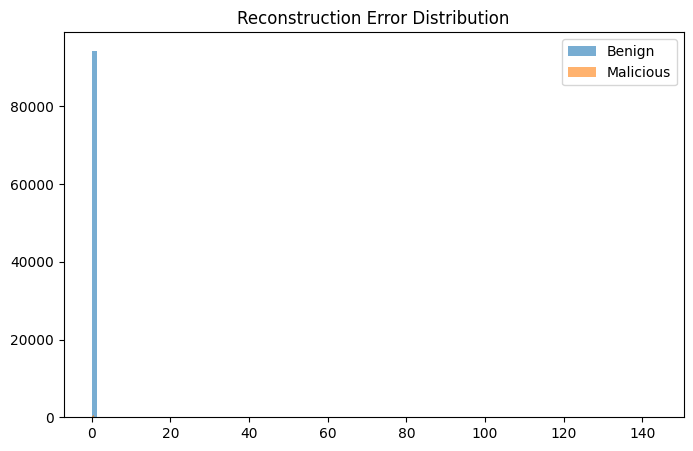

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(benign_errors, bins=100, alpha=0.6, label='Benign')
plt.hist(malicious_errors, bins=100, alpha=0.6, label='Malicious')
plt.legend()
plt.title("Reconstruction Error Distribution")
plt.show()

In [52]:
#Use 95th percentile of benign errors.5% of benign may be flagged.This gives controlled false positive rate.
threshold = np.percentile(benign_errors, 95)
print("Threshold:", threshold)

Threshold: 0.16129985667299318


In [54]:
#Convert AE to Binary Predictions
ae_pred = (reconstruction_error > threshold).astype(int)

In [55]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, ae_pred))
print(classification_report(y_test, ae_pred))

[[89829  4728]
 [36783 20583]]
              precision    recall  f1-score   support

           0       0.71      0.95      0.81     94557
           1       0.81      0.36      0.50     57366

    accuracy                           0.73    151923
   macro avg       0.76      0.65      0.66    151923
weighted avg       0.75      0.73      0.69    151923



In [56]:
# RF predictions already computed as y_pred
#Hybrid prediction
hybrid_pred = np.where(
    y_pred == 1,
    1,
    ae_pred
)

print(confusion_matrix(y_test, hybrid_pred))
print(classification_report(y_test, hybrid_pred))

[[89821  4736]
 [   15 57351]]
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     94557
           1       0.92      1.00      0.96     57366

    accuracy                           0.97    151923
   macro avg       0.96      0.97      0.97    151923
weighted avg       0.97      0.97      0.97    151923



In [57]:
import pandas as pd
import numpy as np

# Load individually again
monday = pd.read_csv("Monday-WorkingHours.pcap_ISCX.csv")
ddos = pd.read_csv("Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
portscan = pd.read_csv("Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv")

for df_temp in [monday, ddos, portscan]:
    df_temp.columns = df_temp.columns.str.strip()

# Add source tag
monday["SourceFile"] = "Monday"
ddos["SourceFile"] = "Friday_DDoS"
portscan["SourceFile"] = "Friday_PortScan"

df_raw = pd.concat([monday, ddos, portscan], axis=0)

# Clean
df_raw = df_raw.replace([np.inf, -np.inf], np.nan)
df_raw = df_raw.dropna()

# Binary label
df_raw["Label"] = df_raw["Label"].apply(lambda x: 0 if x == "BENIGN" else 1)

df_raw.shape

(1041288, 80)

In [58]:
selected_features = [
    'Destination Port',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Min Packet Length',
    'Max Packet Length',
    'Packet Length Mean',
    'Packet Length Std',
    'Flow Duration',
    'Flow IAT Mean',
    'Flow IAT Std',
    'SYN Flag Count',
    'ACK Flag Count',
    'FIN Flag Count',
    'RST Flag Count',
    'PSH Flag Count'
]

df_minimal = df_raw[selected_features + ["Label", "SourceFile"]]

In [59]:
from sklearn.model_selection import train_test_split

# Separate by source
monday_data = df_minimal[df_minimal["SourceFile"] == "Monday"]
friday_data = df_minimal[df_minimal["SourceFile"] != "Monday"]

# Split Friday into train/test
friday_train, friday_test = train_test_split(
    friday_data,
    test_size=0.3,
    random_state=42,
    stratify=friday_data["Label"]
)

# Combine
train_df = pd.concat([monday_data, friday_train])
test_df = friday_test

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (887745, 19)
Test shape: (153543, 19)


In [60]:
X_train = train_df[selected_features]
y_train = train_df["Label"]

X_test = test_df[selected_features]
y_test = test_df["Label"]

from sklearn.preprocessing import StandardScaler

scaler_time = StandardScaler()
X_train_scaled = scaler_time.fit_transform(X_train)
X_test_scaled = scaler_time.transform(X_test)

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_time = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1,
    random_state=42
)

rf_time.fit(X_train, y_train)

y_pred_time = rf_time.predict(X_test)

print(confusion_matrix(y_test, y_pred_time))
print(classification_report(y_test, y_pred_time))

[[67494     0]
 [   35 86014]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     67494
           1       1.00      1.00      1.00     86049

    accuracy                           1.00    153543
   macro avg       1.00      1.00      1.00    153543
weighted avg       1.00      1.00      1.00    153543



In [62]:
import joblib

# Save Random Forest
joblib.dump(rf_time, "rf_model.pkl")

# Save scaler
joblib.dump(scaler_time, "scaler.pkl")

# Save threshold
threshold = np.percentile(benign_errors, 95)
joblib.dump(threshold, "ae_threshold.pkl")

# Save autoencoder
autoencoder.save("autoencoder_model.h5")

In [63]:
#Save feature order
joblib.dump(selected_features, "feature_order.pkl")

['feature_order.pkl']

In [65]:
# Reconstruct time-based test samples
X_test_pred_time = autoencoder.predict(X_test_scaled, batch_size=1024)

# Compute reconstruction error
reconstruction_error_time = np.mean(
    np.square(X_test_scaled - X_test_pred_time),
    axis=1
)

print("Length of reconstruction_error_time:", len(reconstruction_error_time))
print("Length of y_test:", len(y_test))

150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Length of reconstruction_error_time: 153543
Length of y_test: 153543


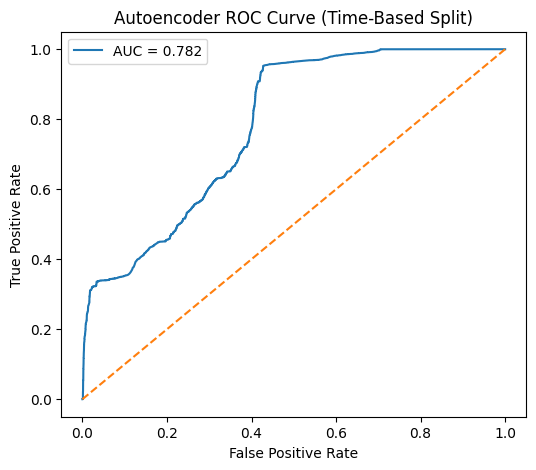

np.float64(0.7819425252940129)

In [66]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, reconstruction_error_time)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Autoencoder ROC Curve (Time-Based Split)")
plt.legend()
plt.show()

roc_auc

In [70]:
def predict_flow(flow_features_dict):

    feature_vector = pd.DataFrame(
        [flow_features_dict],
        columns=selected_features
    )

    rf_pred = rf_time.predict(feature_vector)[0]

    if rf_pred == 1:
        return 1

    scaled_vector = scaler_time.transform(feature_vector)
    reconstructed = autoencoder.predict(scaled_vector, verbose=0)
    error = np.mean(np.square(scaled_vector - reconstructed))

    if error > threshold:
        return 1
    else:
        return 0

In [71]:
rf_time.set_params(n_jobs=1)

RandomForestClassifier(n_jobs=1, random_state=42)

In [72]:
import time

sample = X_test.iloc[0].to_dict()

start = time.time()

for _ in range(200):
    predict_flow(sample)

end = time.time()

avg_time = (end - start) / 200

print("Average inference time per flow (seconds):", avg_time)
print("In milliseconds:", avg_time * 1000)

Average inference time per flow (seconds): 0.0173853600025177
In milliseconds: 17.3853600025177
